### Calculate error statistics for marginal hyperposteriors

The error statistic measures the information lost to Monte Carlo approximations in the *full*, multidimensional hyperposterior. Often we care about the one-dimensional marginals, and some of these may be stable to Monte Carlo uncertainty even when the full posterior is not. `marginal_error_statistics` computes the error, precision and accuracy statistics separately for the marginal posterior of each hyperparameter, so it can be read as a per-parameter convergence diagnostic (somewhat like $\hat{R}$).

Write $\Lambda = (\Lambda', x)$, where $x$ is the hyperparameter of interest. The Monte Carlo noise $\delta(\Lambda) = \ln\hat{\mathcal{L}}(\Lambda) - \ln\mathcal{L}(\Lambda)$ perturbs the marginal posterior $p(x)$ only through its conditional average $\bar\delta(x) = \int d\Lambda'\, p(\Lambda'|x)\, \delta(\Lambda', x)$. The marginal precision statistic replaces ${\rm Var}[\delta(\Lambda)]$ in the full precision statistic with

$$\mathbb{E}_{x}\, {\rm Var}[\bar\delta(x)] = \mathbb{E}\, {\rm Cov}\big[\delta(\Lambda'_1, x),\, \delta(\Lambda'_2, x)\big], \qquad \Lambda'_1, \Lambda'_2 \sim p(\Lambda' | x) \text{ independently}.$$

This is estimated by pairing each hyperposterior sample with its $K$ nearest neighbours in $x$. The neighbours are chosen using $x$ alone, so their $\Lambda'$ are independent draws from $p(\Lambda' | x)$ at nearly the same $x$. The marginal precision always lies between 0 and the full precision.

We use the same GWTC-3 data and population model as the `gwpopulation` example.

In [1]:
import gwpopulation
gwpopulation.set_backend('jax')
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from bilby.core.result import read_in_result
from bilby.hyper.model import Model
# load in population-error package
from population_error import marginal_error_statistics

Load in injection set and posterior set

In [2]:
# dictionary of injections, containing arrays of shape (Ninj). Must contain 'prior' key and should also contain 'total_generated'
# adapted from publicly available GW injections at https://zenodo.org/records/7890398
with h5py.File('data/GWTC3_injections.h5') as f:
    injections = {k: f[k][()] for k in f.keys()}
    
# dictionary of gw samples, containing arrays of shape (Nobs, NPE). Must contain 'prior' key
# adapted from publicly available GW posteriors at https://zenodo.org/records/6513631 and https://zenodo.org/records/8177023
with h5py.File('data/GWTC3_posteriors.h5') as f:
    event_posteriors = {k: f[k][()] for k in f.keys()}

Create gwpopulation model

In [3]:
model_list = [
    gwpopulation.models.mass.SinglePeakSmoothedMassDistribution(), 
    gwpopulation.models.spin.iid_spin,
    gwpopulation.models.redshift.PowerLawRedshift()
    ]

model_function = Model(model_list, cache=False)

vt_model_list = [
    gwpopulation.models.mass.SinglePeakSmoothedMassDistribution(), 
    gwpopulation.models.spin.iid_spin,
    gwpopulation.models.redshift.PowerLawRedshift()
    ]

vt_model_function = Model(vt_model_list, cache=False)

Load in hyperposterior samples

In [4]:
# copied from GWTC-3 data release at https://zenodo.org/records/11254021 (analyses_PowerLawPeak.tar.gz)
gwtc3_result = read_in_result('data/o1o2o3_mass_c_iid_mag_iid_tilt_powerlaw_redshift_result.json')
hyperposterior = gwtc3_result.posterior

Calculate marginal error statistics. The posterior also contains derived columns (e.g. `log_likelihood`, `rate`), so we restrict the marginals to the sampled hyperparameters with `parameters`. All columns are still used to identify repeated samples.

`k_neighbours` sets how many nearest neighbours in $x$ are averaged over for each sample. The noise in each marginal estimate is set by the size of the *full* precision statistic and falls as $1/\sqrt{N_{\rm samp} K}$, so a larger $K$ reduces the noise, at the cost of pairing samples at slightly different $x$. With $\sim 10^4$ hyperposterior samples, $K \sim 10$ is a reasonable choice.

The cost is roughly $(2 + N_{\rm parameters})$ population-model evaluations per hyperposterior sample: one pass for the full statistics, plus one pass for each marginal.

In [5]:
statistics = marginal_error_statistics(
    model_function, 
    injections, 
    event_posteriors, 
    hyperposterior, 
    parameters=gwtc3_result.search_parameter_keys,
    k_neighbours=10,
    vt_model_function=vt_model_function,
    include_likelihood_correction=True, 
    conversion_function=gwpopulation.conversions.convert_to_beta_parameters
    )

Nobs not provided, assuming Nobs = 69


Computing single event covariance weights integrated over hyperposterior samples: 100%|██████████| 11469/11469 [00:23<00:00, 496.80it/s]
Computing selection covariance weights integrated over hyperposterior samples: 100%|██████████| 11469/11469 [00:13<00:00, 834.21it/s]
For each posterior sample, average single event covariance with another posterior sample: 100%|██████████| 11469/11469 [00:20<00:00, 550.00it/s]
For each posterior sample, average selection covariance with another posterior sample: 100%|██████████| 11469/11469 [00:13<00:00, 846.65it/s]
Nearest-neighbour covariances in lamb: 100%|██████████| 11469/11469 [00:33<00:00, 341.22it/s]


parameter        error   precision    accuracy  precision / joint
joint           0.2635      0.2552    0.008273              1.000
alpha          0.01724      0.0171   0.0001377              0.067
beta           0.02918     0.02757    0.001609              0.108
mmax          0.003384    0.003468   -8.46e-05              0.014
mmin          0.005487     0.00559  -0.0001037              0.022
lam           0.006638    0.006524    0.000114              0.026
mpp            0.03117     0.03099   0.0001737              0.121
sigpp          0.03636     0.03473    0.001624              0.136
delta_m       0.005507    0.005337   0.0001697              0.021
mu_chi         0.04167     0.04066    0.001009              0.159
sigma_chi       0.0299     0.02971   0.0001949              0.116
xi_spin       0.003608    0.003515   9.352e-05              0.014
sigma_spin     0.02149     0.02113     0.00036              0.083
lamb             0.018      0.0178   0.0001939              0.070
(statisti

The results are returned as a dictionary, with the full-posterior statistics under `'joint'` and the per-parameter statistics under `'marginal'`.

In [6]:
marginal = pd.DataFrame(statistics['marginal']).T
marginal['precision / joint'] = marginal['precision_statistic'] / statistics['joint']['precision_statistic']
marginal.sort_values('precision_statistic', ascending=False)

,error_statistic,precision_statistic,accuracy_statistic,precision / joint
mu_chi,0.041668,0.040659,0.001009,0.159326
sigpp,0.036357,0.034733,0.001624,0.136105
mpp,0.031168,0.030995,0.000174,0.121454
sigma_chi,0.029903,0.029708,0.000195,0.116412
beta,0.029175,0.027566,0.001609,0.108019
sigma_spin,0.021486,0.021126,0.000360,0.082783
lamb,0.017998,0.017804,0.000194,0.069767
alpha,0.017238,0.017100,0.000138,0.067008
lam,0.006638,0.006524,0.000114,0.025565
mmin,0.005487,0.005590,-0.000104,0.021906


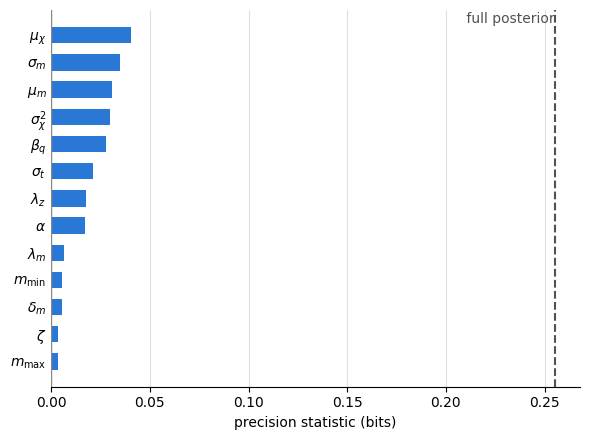

In [7]:
labels = {k: gwtc3_result.priors[k].latex_label for k in marginal.index}
order = marginal.sort_values('precision_statistic').index

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.barh([labels[k] for k in order], marginal.loc[order, 'precision_statistic'], height=0.6, color='#2a78d6')
ax.axvline(statistics['joint']['precision_statistic'], color='#52514e', ls='--', lw=1.5)
ax.text(statistics['joint']['precision_statistic'], len(order) - 0.4, ' full posterior', color='#52514e', va='center', ha='right')
ax.axvline(0, color='#898781', lw=1)
ax.set_xlabel('precision statistic (bits)')
ax.grid(axis='x', color='#e1e0d9', lw=0.8)
ax.set_axisbelow(True)
for side in ('top', 'right', 'left'):
    ax.spines[side].set_visible(False)
ax.tick_params(axis='y', length=0)
plt.tight_layout()
plt.show()

The full hyperposterior loses about 0.26 bits to Monte Carlo approximations, the same as in the `gwpopulation` example. Every one-dimensional marginal is much more stable: each marginal precision statistic is at most 16% of the full one, between 0.004 and 0.04 bits. Much of the Monte Carlo noise in the likelihood moves the posterior along combinations of hyperparameters, and this is averaged away when the other hyperparameters are marginalized over.

The marginals are not equally sensitive. The spin magnitude parameters ($\mu_\chi$, $\sigma^2_\chi$) and the Gaussian peak ($\mu_m$, $\sigma_m$) lose the most information, while $m_{\max}$, $\zeta$, $\delta_m$, $m_{\min}$ and $\lambda_m$ lose almost none. So if the error statistic of the full posterior is above your tolerance, it is worth checking the marginals of the parameters you actually care about, which may still be within it. Conversely, the parameters near the top of this list are the first to become unreliable as the number of injections or posterior samples decreases.

As in the full posterior, uncertainty dominates over bias: the marginal accuracy statistics are at most $\sim 2\times 10^{-3}$ bits.

The marginal statistics are estimates from a finite number of hyperposterior samples. This posterior was resampled from a nested-sampling run, so its 11469 samples contain only 5639 distinct sets of population hyperparameters (the post-processed `rate` column differs between copies); copies are identified automatically and never paired with each other. The estimates are noisier for parameters whose marginal statistic is much smaller than the full one: `marginal_error_statistics_matrix` also reports a null distribution, which here has a standard deviation of $\sim 8\times 10^{-4}$ bits, so the smallest marginals above are only a few times this noise level. Rerunning with a different `k_neighbours` is a quick check that the ordering above is robust.